In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('2024data.csv')
df

,ISBE_CPRD_KEY,Strata,r_grade,r_age,gender,gen_ident,lgbtq,r_white,r_black,r_latino,...,sta_encg,sc_int,sc_dec,sc_diff,sc_close,sc_happy,sc_safe,sc_fair,adlt_knw,honest
0,21027,Rural,8th,13.0,Female,Yes,NaN,Yes,No,No,...,A little true,Very much true,Not at all true,A little true,Neither agree nor disagree,Agree,Strongly agree,Agree,No,I was honest pretty much of the time
1,21900,Chicago,10th,15.0,Male,Yes,Heterosexual or straight,Yes,No,Yes,...,Pretty much true,A little true,A little true,A little true,Neither agree nor disagree,Neither agree nor disagree,Agree,Disagree,"Yes, more than one adult",I was honest pretty much of the time
2,20970,Suburban Chicago,11th,17.0,Male,Yes,Heterosexual or straight,No,No,No,...,Pretty much true,Very much true,A little true,Pretty much true,Disagree,Neither agree nor disagree,Strongly agree,Strongly agree,No,I was very honest
3,19140,Suburban Chicago,12th,17.0,Female,NaN,NaN,Yes,No,No,...,Very much true,Very much true,Very much true,Very much true,Strongly agree,Strongly agree,Strongly agree,Strongly agree,"Yes, more than one adult",I was very honest
4,13266,Rural,8th,14.0,Male,NaN,NaN,Yes,No,No,...,Pretty much true,Very much true,Very much true,Very much true,Strongly agree,Strongly agree,Strongly agree,Strongly agree,"Yes, more than one adult",I was very honest
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141170,14451,Suburban Chicago,11th,17.0,Prefer not to answer,NaN,NaN,Yes,No,No,...,Very much true,Very much true,A little true,Very much true,Agree,Disagree,Disagree,Strongly agree,"Yes, more than one adult",I was very honest
141171,28173,Suburban Chicago,10th,16.0,Male,Yes,I don't know what this question is asking,No,No,Yes,...,A little true,Not at all true,Not at all true,Not at all true,Neither agree nor disagree,Neither agree nor disagree,Agree,Neither agree nor disagree,"Yes, more than one adult",I was very honest
141172,13980,Suburban Chicago,9th,15.0,Female,NaN,NaN,No,No,No,...,A little true,Pretty much true,A little true,A little true,Agree,Agree,Agree,Neither agree nor disagree,"Yes, more than one adult",I was honest pretty much of the time
141173,14136,Suburban Chicago,11th,17.0,Male,Yes,Heterosexual or straight,Yes,No,No,...,Very much true,Pretty much true,Pretty much true,A little true,Agree,Agree,Agree,Agree,"Yes, more than one adult",I was very honest


In [4]:
df_8 = df[df["r_grade"] == "8th"]
df_8

,ISBE_CPRD_KEY,Strata,r_grade,r_age,gender,gen_ident,lgbtq,r_white,r_black,r_latino,...,sta_encg,sc_int,sc_dec,sc_diff,sc_close,sc_happy,sc_safe,sc_fair,adlt_knw,honest
0,21027,Rural,8th,13.0,Female,Yes,NaN,Yes,No,No,...,A little true,Very much true,Not at all true,A little true,Neither agree nor disagree,Agree,Strongly agree,Agree,No,I was honest pretty much of the time
4,13266,Rural,8th,14.0,Male,NaN,NaN,Yes,No,No,...,Pretty much true,Very much true,Very much true,Very much true,Strongly agree,Strongly agree,Strongly agree,Strongly agree,"Yes, more than one adult",I was very honest
14,17709,Suburban Chicago,8th,13.0,Male,NaN,NaN,Yes,No,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Yes, more than one adult",I was very honest
15,16545,Other Urban/Suburban,8th,13.0,Male,NaN,NaN,Yes,No,No,...,Pretty much true,Pretty much true,A little true,Pretty much true,Agree,Strongly agree,Strongly agree,Strongly agree,"Yes, more than one adult",I was honest pretty much of the time
17,10452,Suburban Chicago,8th,14.0,Male,NaN,NaN,Yes,No,No,...,Very much true,A little true,A little true,A little true,Agree,Neither agree nor disagree,Agree,Agree,"Yes, one adult",I was very honest
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141164,12969,Suburban Chicago,8th,13.0,Female,Yes,Bisexual,No,No,Yes,...,Not at all true,A little true,A little true,A little true,Agree,Disagree,Disagree,Disagree,"Yes, one adult",NaN
141165,16623,Suburban Chicago,8th,13.0,Male,NaN,NaN,Yes,No,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Yes, one adult",I was honest pretty much of the time
141166,23988,Suburban Chicago,8th,13.0,Female,Yes,I don't know what this question is asking,Yes,No,Yes,...,Not at all true,Not at all true,Not at all true,Not at all true,Neither agree nor disagree,Strongly disagree,Disagree,Strongly disagree,"Yes, more than one adult",I was honest some of the time
141168,21468,Chicago,8th,13.0,Male,NaN,NaN,No,No,Yes,...,Pretty much true,Pretty much true,Pretty much true,Pretty much true,Neither agree nor disagree,Agree,Agree,Agree,"Yes, one adult",I was very honest


In [5]:
import statsmodels.formula.api as smf


In [6]:
df["binge"].value_counts()

binge
Never               130985
Once                  3440
Twice                 1685
3-5 times              976
6-9 times              282
10 or more times       282
Name: count, dtype: int64

In [7]:
#binary binge variable 
df_8["binge_binary"] = (df["binge"] != "Never").astype(int)
df_8["binge_binary"].value_counts()

C:\Users\saraz\AppData\Local\Temp\ipykernel_6600\1892265064.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_8["binge_binary"] = (df["binge"] != "Never").astype(int)


binge_binary
0    36945
1     3514
Name: count, dtype: int64

In [8]:
import statsmodels.formula.api as smf

model = smf.ols(
'binge_binary ~ r_black + r_latino + r_asian + r_natam + r_multir + r_other + frlunch',
data=df_8
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           binge_binary   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     30.80
Date:                Tue, 21 Apr 2026   Prob (F-statistic):           1.45e-48
Time:                        20:28:36   Log-Likelihood:                -5736.3
No. Observations:               39587   AIC:                         1.149e+04
Df Residuals:                   39578   BIC:                         1.157e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

In [9]:
df["poc"] = (df["r_white"] == 0).astype(int)
df["poc"].value_counts()
df_8["poc"] = (df_8["r_white"] == 0).astype(int)
df_8['poc'].value_counts(dropna=False)

C:\Users\saraz\AppData\Local\Temp\ipykernel_6600\2060220046.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_8["poc"] = (df_8["r_white"] == 0).astype(int)


poc
0    40459
Name: count, dtype: int64

In [10]:
model = smf.ols(
'binge_binary ~ poc + frlunch',
data=df_8
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           binge_binary   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     67.24
Date:                Tue, 21 Apr 2026   Prob (F-statistic):           7.04e-30
Time:                        20:28:36   Log-Likelihood:                -5792.0
No. Observations:               39587   AIC:                         1.159e+04
Df Residuals:                   39584   BIC:                         1.162e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

c:\Users\saraz\Desktop\miniconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


In [11]:
df_8["pot_30"].value_counts()

pot_30
0 occasions             38827
1-2 occasions             586
3-5 occasions             213
20 or more occasions      191
6-9 occasions             135
10-19 occasions           124
Name: count, dtype: int64

In [12]:
df_8["pot_binary"] = (df_8["pot_30"] != "Never").astype(int)

C:\Users\saraz\AppData\Local\Temp\ipykernel_6600\2490836757.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_8["pot_binary"] = (df_8["pot_30"] != "Never").astype(int)


In [13]:
smf.ols(
'pot_binary ~ r_black + r_latino + r_asian + r_natam + r_multir + r_other + frlunch',
data=df_8
).fit().summary()

c:\Users\saraz\Desktop\miniconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             pot_binary   R-squared:                        -inf
Model:                            OLS   Adj. R-squared:                   -inf
Method:                 Least Squares   F-statistic:                    -4947.
Date:                Tue, 21 Apr 2026   Prob (F-statistic):               1.00
Time:                        20:28:37   Log-Likelihood:             1.3127e+06
No. Observations:               39587   AIC:                        -2.625e+06
Df Residuals:                   39578   BIC:                        -2.625e+06
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==================================================================================================
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                          1.0000      9e-18   1.11e+17      0.000       1.000       1.000
r_black[T.Yes]                 -9.684e-16   1.46e-17    -66.469      0.000   -9.97e-16    -9.4e-16
r_latino[T.Yes]                -1.735e-18   1.23e-17     -0.141      0.888   -2.58e-17    2.23e-17
r_asian[T.Yes]                  1.564e-15   1.72e-17     90.758      0.000    1.53e-15     1.6e-15
r_natam[T.Yes]                 -1.051e-15   2.91e-17    -36.068      0.000   -1.11e-15   -9.94e-16
r_multir[T.Yes]                 7.182e-16   2.02e-17     35.574      0.000    6.79e-16    7.58e-16
r_other[T.Yes]                 -1.056e-15   2.28e-17    -46.204      0.000    -1.1e-15   -1.01e-15
frlunch[T.Neither]             -2.446e-16   1.13e-17    -21.725      0.000   -2.67e-16   -2.23e-16
frlunch[T.Reduced price lunch] -8.969e-16   1.65e-17    -54.501      0.000   -9.29e-16   -8.65e-16
==============================================================================
Omnibus:                     1390.196   Durbin-Watson:                   1.052
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2690.866
Skew:                          -0.266   Prob(JB):                         0.00
Kurtosis:                       4.161   Cond. No.                         6.76
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [14]:
model = smf.ols(
'pot_binary ~ poc + frlunch',
data=df_8
).fit()

print(model.summary())

c:\Users\saraz\Desktop\miniconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


                            OLS Regression Results                            
Dep. Variable:             pot_binary   R-squared:                        -inf
Model:                            OLS   Adj. R-squared:                   -inf
Method:                 Least Squares   F-statistic:                -1.979e+04
Date:                Tue, 21 Apr 2026   Prob (F-statistic):               1.00
Time:                        20:28:37   Log-Likelihood:             1.2249e+06
No. Observations:               39587   AIC:                        -2.450e+06
Df Residuals:                   39584   BIC:                        -2.450e+06
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

c:\Users\saraz\Desktop\miniconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


In [15]:
df_8["rsk_bng"].value_counts()
df_8["rsk_dlyp"].value_counts()

rsk_dlyp
Great risk       21219
Moderate risk     9772
Slight risk       5398
No risk           3290
Name: count, dtype: int64

In [16]:
risk_map = {
    "No risk": 1,
    "Slight risk": 2,
    "Moderate risk": 3,
    "Great risk": 4
}


In [17]:
df_8["rsk_bng_num"] = df_8["rsk_bng"].map(risk_map)
df_8["rsk_dlyp_num"] = df_8["rsk_dlyp"].map(risk_map)

C:\Users\saraz\AppData\Local\Temp\ipykernel_6600\2475994756.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_8["rsk_bng_num"] = df_8["rsk_bng"].map(risk_map)
C:\Users\saraz\AppData\Local\Temp\ipykernel_6600\2475994756.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_8["rsk_dlyp_num"] = df_8["rsk_dlyp"].map(risk_map)


In [18]:
df_8["rsk_bng_num"].value_counts(dropna=False)
df_8["rsk_dlyp_num"].value_counts(dropna=False)

rsk_dlyp_num
4.0    21219
3.0     9772
2.0     5398
1.0     3290
NaN      780
Name: count, dtype: int64

In [19]:
model_risk_pot = smf.ols(
    "rsk_dlyp_num ~ r_black + r_latino + r_asian + r_natam + r_multir + r_other + frlunch",
    data=df_8
).fit()

print(model_risk_pot.summary())

                            OLS Regression Results                            
Dep. Variable:           rsk_dlyp_num   R-squared:                       0.041
Model:                            OLS   Adj. R-squared:                  0.041
Method:                 Least Squares   F-statistic:                     209.9
Date:                Tue, 21 Apr 2026   Prob (F-statistic):               0.00
Time:                        20:28:38   Log-Likelihood:                -53248.
No. Observations:               38853   AIC:                         1.065e+05
Df Residuals:                   38844   BIC:                         1.066e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

In [20]:
model = smf.ols(
'rsk_dlyp_num ~ poc + frlunch',
data=df_8
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           rsk_dlyp_num   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                  0.021
Method:                 Least Squares   F-statistic:                     425.5
Date:                Tue, 21 Apr 2026   Prob (F-statistic):          1.53e-183
Time:                        20:28:39   Log-Likelihood:                -53649.
No. Observations:               38853   AIC:                         1.073e+05
Df Residuals:                   38850   BIC:                         1.073e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

c:\Users\saraz\Desktop\miniconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


In [21]:
model = smf.ols(
'rsk_bng_num ~ poc + frlunch',
data=df_8
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            rsk_bng_num   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     139.6
Date:                Tue, 21 Apr 2026   Prob (F-statistic):           3.96e-61
Time:                        20:28:39   Log-Likelihood:                -49784.
No. Observations:               38784   AIC:                         9.957e+04
Df Residuals:                   38781   BIC:                         9.960e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

c:\Users\saraz\Desktop\miniconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


In [22]:
df_8['poc'].value_counts(dropna=False)

poc
0    40459
Name: count, dtype: int64

In [23]:
len(df_8)

40459

# Race Labels

In [24]:
import numpy as np

#Step 1 
race_cols = ["r_white", "r_black", "r_latino", "r_asian", "r_natam", "r_multir", "r_other"]

for col in race_cols:
    df_8[col] = pd.to_numeric(df_8[col], errors="coerce")

#Step 2
df_8["responses_count"] = df_8[race_cols].sum(axis=1)

#Step 3
df_8["race_final"] = np.nan

df_8.loc[df_8["r_white"] == 1, "race_final"] = 0
df_8.loc[df_8["r_black"] == 1, "race_final"] = 1
df_8.loc[df_8["r_latino"] == 1, "race_final"] = 2
df_8.loc[df_8["r_asian"] == 1, "race_final"] = 3
df_8.loc[df_8["r_natam"] == 1, "race_final"] = 4
df_8.loc[df_8["r_multir"] == 1, "race_final"] = 5
df_8.loc[df_8["r_other"] == 1, "race_final"] = 6

df_8.loc[df_8["responses_count"] > 1, "race_final"] = 6

#Step 4
df_8["race_final"].value_counts(dropna=False)

#Step 5
df_8[race_cols].dtypes


C:\Users\saraz\AppData\Local\Temp\ipykernel_6600\2512926986.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_8[col] = pd.to_numeric(df_8[col], errors="coerce")
C:\Users\saraz\AppData\Local\Temp\ipykernel_6600\2512926986.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_8["responses_count"] = df_8[race_cols].sum(axis=1)
C:\Users\saraz\AppData\Local\Temp\ipykernel_6600\2512926986.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_i

r_white     float64
r_black     float64
r_latino    float64
r_asian     float64
r_natam     float64
r_multir    float64
r_other     float64
dtype: object

In [25]:
#Recreate responses_count and race_final
df_8["responses_count"] = df_8[race_cols].sum(axis=1)

df_8["race_final"] = np.nan

df_8.loc[df_8["r_white"] == 1, "race_final"] = 0
df_8.loc[df_8["r_black"] == 1, "race_final"] = 1
df_8.loc[df_8["r_latino"] == 1, "race_final"] = 2
df_8.loc[df_8["r_asian"] == 1, "race_final"] = 3
df_8.loc[df_8["r_natam"] == 1, "race_final"] = 4
df_8.loc[df_8["r_multir"] == 1, "race_final"] = 5
df_8.loc[df_8["r_other"] == 1, "race_final"] = 6

df_8.loc[df_8["responses_count"] > 1, "race_final"] = 6

#check 
df_8["race_final"].value_counts(dropna=False)

C:\Users\saraz\AppData\Local\Temp\ipykernel_6600\255517310.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_8["responses_count"] = df_8[race_cols].sum(axis=1)
C:\Users\saraz\AppData\Local\Temp\ipykernel_6600\255517310.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_8["race_final"] = np.nan


race_final
NaN    40459
Name: count, dtype: int64

In [26]:
for col in race_cols:
    print(col)
    print(df_8[col].value_counts(dropna=False).head(10))
    print()
df_8[race_cols].head(10)
df_8[race_cols].isna().sum()

r_white
r_white
NaN    40459
Name: count, dtype: int64

r_black
r_black
NaN    40459
Name: count, dtype: int64

r_latino
r_latino
NaN    40459
Name: count, dtype: int64

r_asian
r_asian
NaN    40459
Name: count, dtype: int64

r_natam
r_natam
NaN    40459
Name: count, dtype: int64

r_multir
r_multir
NaN    40459
Name: count, dtype: int64

r_other
r_other
NaN    40459
Name: count, dtype: int64



r_white     40459
r_black     40459
r_latino    40459
r_asian     40459
r_natam     40459
r_multir    40459
r_other     40459
dtype: int64

In [27]:
#original 
df_8[["r_white","r_black","r_latino","r_asian","r_natam","r_multir","r_other"]].head(10)

for col in ["r_white","r_black","r_latino","r_asian","r_natam","r_multir","r_other"]:
    print(col)
    print(df_8[col].astype(str).value_counts(dropna=False).head(10))
    print()

r_white
r_white
nan    40459
Name: count, dtype: int64

r_black
r_black
nan    40459
Name: count, dtype: int64

r_latino
r_latino
nan    40459
Name: count, dtype: int64

r_asian
r_asian
nan    40459
Name: count, dtype: int64

r_natam
r_natam
nan    40459
Name: count, dtype: int64

r_multir
r_multir
nan    40459
Name: count, dtype: int64

r_other
r_other
nan    40459
Name: count, dtype: int64



In [28]:
for col in ["r_white","r_black","r_latino","r_asian","r_natam","r_multir","r_other"]:
    print(col, df_8[col].head(5).tolist())
df_8[["r_white","r_black","r_latino","r_asian","r_natam","r_multir","r_other"]].head(5)


r_white [nan, nan, nan, nan, nan]
r_black [nan, nan, nan, nan, nan]
r_latino [nan, nan, nan, nan, nan]
r_asian [nan, nan, nan, nan, nan]
r_natam [nan, nan, nan, nan, nan]
r_multir [nan, nan, nan, nan, nan]
r_other [nan, nan, nan, nan, nan]


,r_white,r_black,r_latino,r_asian,r_natam,r_multir,r_other
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
print(df.columns)

Index(['ISBE_CPRD_KEY', 'Strata', 'r_grade', 'r_age', 'gender', 'gen_ident',
       'lgbtq', 'r_white', 'r_black', 'r_latino', 'r_asian', 'r_natam',
       'r_multir', 'r_other', 'lv_bothp', 'lv_pstep', 'lv_motho', 'lv_fatho',
       'lv_splitp', 'lv_legal', 'lv_fosp', 'lv_gphom', 'lv_grand', 'lv_ind',
       'zipcode', 'frlunch', 'absent', 'alco_get', 'toba_get', 'pot_get',
       'rsk_1pac', 'rsk_alc', 'rsk_bng', 'rsk_dlyp', 'cool_cig', 'cool_alc',
       'cool_pot', 'rsktn_alc', 'chew_30', 'smtob_30', 'binge', 'pot_30',
       'par_tob', 'par_alc', 'par_potr', 'fna_drul', 'sta_care', 'sta_notc',
       'sta_lstn', 'sta_tlrn', 'sta_gjob', 'sta_best', 'sta_bels', 'sta_encg',
       'sc_int', 'sc_dec', 'sc_diff', 'sc_close', 'sc_happy', 'sc_safe',
       'sc_fair', 'adlt_knw', 'honest', 'poc'],
      dtype='object')


In [30]:
#remake 
df[["r_white","r_black","r_latino","r_asian","r_natam","r_multir","r_other"]].head()

df_8 = df[df["r_grade"] == 8].copy()
df_8[["r_white","r_black","r_latino","r_asian","r_natam","r_multir","r_other"]].head()
for col in ["r_white","r_black","r_latino","r_asian","r_natam","r_multir","r_other"]:
    print(col)
    print(df_8[col].value_counts(dropna=False).head(10))
    print()

r_white
Series([], Name: count, dtype: int64)

r_black
Series([], Name: count, dtype: int64)

r_latino
Series([], Name: count, dtype: int64)

r_asian
Series([], Name: count, dtype: int64)

r_natam
Series([], Name: count, dtype: int64)

r_multir
Series([], Name: count, dtype: int64)

r_other
Series([], Name: count, dtype: int64)



In [31]:
#see what it has 
df["r_grade"].value_counts(dropna=False)

r_grade
8th     40459
10th    39895
12th    26162
9th     18203
11th    16456
Name: count, dtype: int64

In [32]:
df_8 = df[df["r_grade"] == "8th"].copy()
for col in ["r_white","r_black","r_latino","r_asian","r_natam","r_multir","r_other"]:
    print(col)
    print(df_8[col].value_counts(dropna=False).head(10))
    print()

r_white
r_white
Yes    21500
No     18959
Name: count, dtype: int64

r_black
r_black
No     34720
Yes     5739
Name: count, dtype: int64

r_latino
r_latino
No     31247
Yes     9212
Name: count, dtype: int64

r_asian
r_asian
No     36838
Yes     3621
Name: count, dtype: int64

r_natam
r_natam
No     39315
Yes     1144
Name: count, dtype: int64

r_multir
r_multir
No     37978
Yes     2481
Name: count, dtype: int64

r_other
r_other
No     38551
Yes     1908
Name: count, dtype: int64



In [33]:
#fix
import numpy as np

df_8 = df[df["r_grade"] == "8th"].copy()

race_cols = ["r_white","r_black","r_latino","r_asian","r_natam","r_multir","r_other"]

# Count how many races selected
df_8["responses_count"] = (df_8[race_cols] == "Yes").sum(axis=1)

# Create race_final
df_8["race_final"] = np.nan

df_8.loc[df_8["r_white"] == "Yes", "race_final"] = 0
df_8.loc[df_8["r_black"] == "Yes", "race_final"] = 1
df_8.loc[df_8["r_latino"] == "Yes", "race_final"] = 2
df_8.loc[df_8["r_asian"] == "Yes", "race_final"] = 3
df_8.loc[df_8["r_natam"] == "Yes", "race_final"] = 4
df_8.loc[df_8["r_multir"] == "Yes", "race_final"] = 5
df_8.loc[df_8["r_other"] == "Yes", "race_final"] = 6

# Multiple race → Other
df_8.loc[df_8["responses_count"] > 1, "race_final"] = 6

df_8["race_final"].value_counts(dropna=False)

race_final
0.0    18627
2.0     7122
6.0     5269
1.0     4278
3.0     2889
5.0     1607
4.0      420
NaN      247
Name: count, dtype: int64

In [34]:
#poc
df_8["poc_fixed"] = np.where(df_8["race_final"] == 0, 0, 1)

df_8["poc_fixed"].value_counts()


poc_fixed
1    21832
0    18627
Name: count, dtype: int64

In [35]:
df_8["race_final"].value_counts(dropna=False)

race_final
0.0    18627
2.0     7122
6.0     5269
1.0     4278
3.0     2889
5.0     1607
4.0      420
NaN      247
Name: count, dtype: int64

In [36]:
#poc creation 
df_8["poc_fixed"] = np.where(df_8["race_final"] == 0, 0, 1)

df_8["poc_fixed"].value_counts(dropna=False)

poc_fixed
1    21832
0    18627
Name: count, dtype: int64

In [37]:
#binge binary results
df_8["binge_binary"] = (df_8["binge"] != "Never").astype(int)

df_8["binge_binary"].value_counts()

model = smf.ols(
    "binge_binary ~ poc_fixed + frlunch",
    data=df_8
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           binge_binary   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     56.87
Date:                Tue, 21 Apr 2026   Prob (F-statistic):           1.12e-36
Time:                        20:28:40   Log-Likelihood:                -5774.0
No. Observations:               39587   AIC:                         1.156e+04
Df Residuals:                   39583   BIC:                         1.159e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

In [38]:
#marijuana use results
df_8["pot_binary"] = (df_8["pot_30"] != "0 occasions").astype(int)

model = smf.ols(
    "pot_binary ~ poc_fixed + frlunch",
    data=df_8
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             pot_binary   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     141.8
Date:                Tue, 21 Apr 2026   Prob (F-statistic):           2.24e-91
Time:                        20:28:40   Log-Likelihood:                 8518.7
No. Observations:               39587   AIC:                        -1.703e+04
Df Residuals:                   39583   BIC:                        -1.700e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

In [39]:
#risk of binge drinking results

risk_map = {
    "No risk": 1,
    "Slight risk": 2,
    "Moderate risk": 3,
    "Great risk": 4
}

df_8["rsk_bng_num"] = df_8["rsk_bng"].map(risk_map)

df_8["rsk_bng_num"].value_counts(dropna=False)
model = smf.ols(
    "rsk_bng_num ~ poc_fixed + frlunch",
    data=df_8
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            rsk_bng_num   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     97.57
Date:                Tue, 21 Apr 2026   Prob (F-statistic):           6.53e-63
Time:                        20:28:40   Log-Likelihood:                -49777.
No. Observations:               38784   AIC:                         9.956e+04
Df Residuals:                   38780   BIC:                         9.960e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

In [40]:
#marijuana use risk 

risk_map = {
    "No risk": 1,
    "Slight risk": 2,
    "Moderate risk": 3,
    "Great risk": 4
}

df_8["rsk_dlyp_num"] = df_8["rsk_dlyp"].map(risk_map)

df_8["rsk_dlyp_num"].value_counts(dropna=False)
model = smf.ols(
    "rsk_dlyp_num ~ poc_fixed + frlunch",
    data=df_8
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           rsk_dlyp_num   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     294.6
Date:                Tue, 21 Apr 2026   Prob (F-statistic):          4.09e-189
Time:                        20:28:41   Log-Likelihood:                -53633.
No. Observations:               38853   AIC:                         1.073e+05
Df Residuals:                   38849   BIC:                         1.073e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

# Graphs

In [41]:
import statsmodels.formula.api as smf

# binary outcomes
model_binge = smf.ols("binge_binary ~ poc_fixed + frlunch", data=df_8).fit()
model_pot = smf.ols("pot_binary ~ poc_fixed + frlunch", data=df_8).fit()

# risk outcomes
model_risk_binge = smf.ols("rsk_bng_num ~ poc_fixed + frlunch", data=df_8).fit()
model_risk_pot = smf.ols("rsk_dlyp_num ~ poc_fixed + frlunch", data=df_8).fit()

In [42]:
import pandas as pd

pred_df = pd.DataFrame({
    "poc_fixed": [0, 1, 0, 1, 0, 1],
    "frlunch": [
        "Free lunch", "Free lunch",
        "Reduced price lunch", "Reduced price lunch",
        "Neither", "Neither"
    ]
})

pred_df["race_group"] = ["White", "Non-white", "White", "Non-white", "White", "Non-white"]

In [43]:
pred_df["binge_pred"] = model_binge.predict(pred_df)
pred_df["pot_pred"] = model_pot.predict(pred_df)
pred_df["risk_binge_pred"] = model_risk_binge.predict(pred_df)
pred_df["risk_pot_pred"] = model_risk_pot.predict(pred_df)


In [44]:
pred_df["binge_pred_pct"] = pred_df["binge_pred"] * 100
pred_df["pot_pred_pct"] = pred_df["pot_pred"] * 100

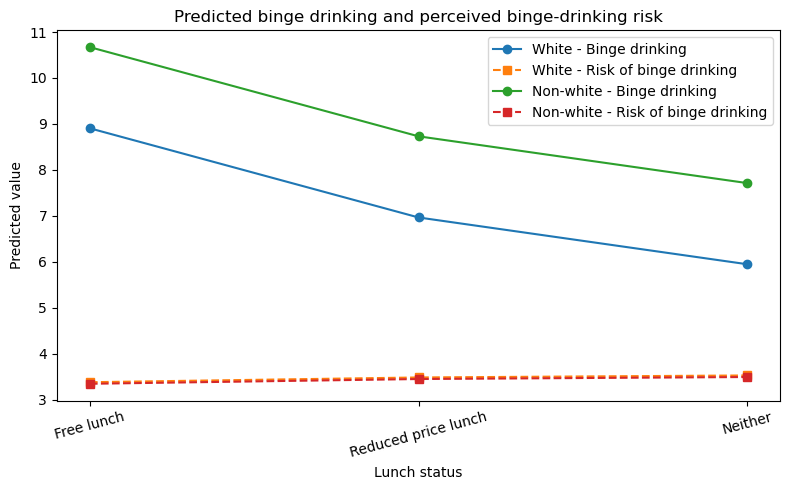

In [47]:
import matplotlib.pyplot as plt

order = ["Free lunch", "Reduced price lunch", "Neither"]

fig, ax = plt.subplots(figsize=(8, 5))

for race in ["White", "Non-white"]:
    sub = pred_df[pred_df["race_group"] == race].copy()
    sub["frlunch"] = pd.Categorical(sub["frlunch"], categories=order, ordered=True)
    sub = sub.sort_values("frlunch")
    ax.plot(sub["frlunch"], sub["binge_pred_pct"], marker="o", label=f"{race} - Binge drinking")
    ax.plot(sub["frlunch"], sub["risk_binge_pred"], marker="s", linestyle="--", label=f"{race} - Risk of binge drinking")

ax.set_title("Predicted binge drinking and perceived binge-drinking risk")
ax.set_xlabel("Lunch status")
ax.set_ylabel("Predicted value")
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

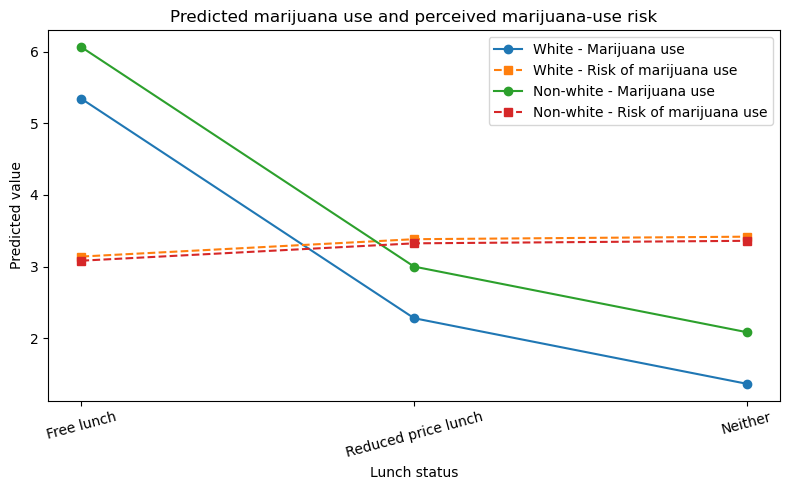

In [48]:
fig, ax = plt.subplots(figsize=(8, 5))

for race in ["White", "Non-white"]:
    sub = pred_df[pred_df["race_group"] == race].copy()
    sub["frlunch"] = pd.Categorical(sub["frlunch"], categories=order, ordered=True)
    sub = sub.sort_values("frlunch")
    ax.plot(sub["frlunch"], sub["pot_pred_pct"], marker="o", label=f"{race} - Marijuana use")
    ax.plot(sub["frlunch"], sub["risk_pot_pred"], marker="s", linestyle="--", label=f"{race} - Risk of marijuana use")

ax.set_title("Predicted marijuana use and perceived marijuana-use risk")
ax.set_xlabel("Lunch status")
ax.set_ylabel("Predicted value")
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

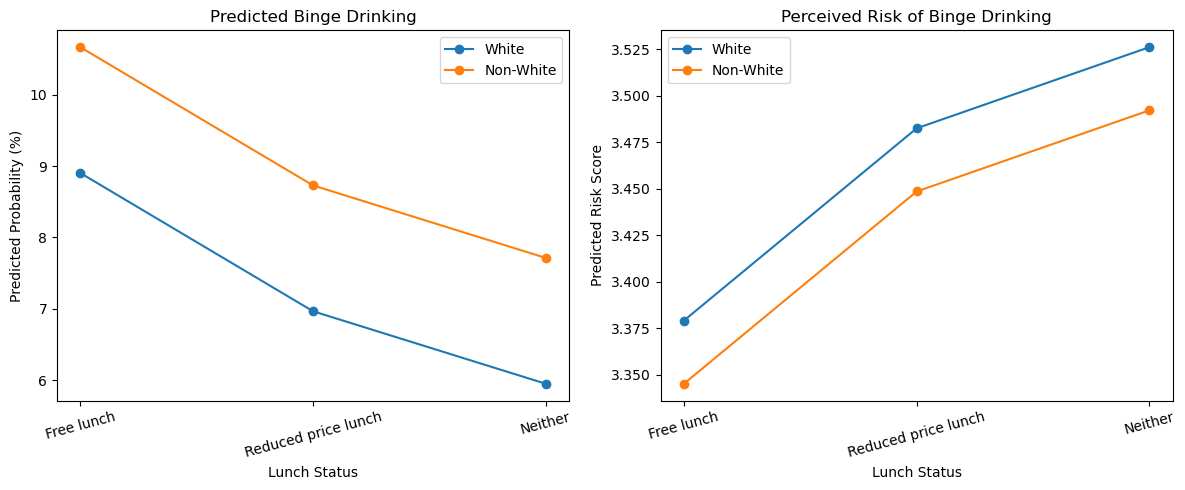

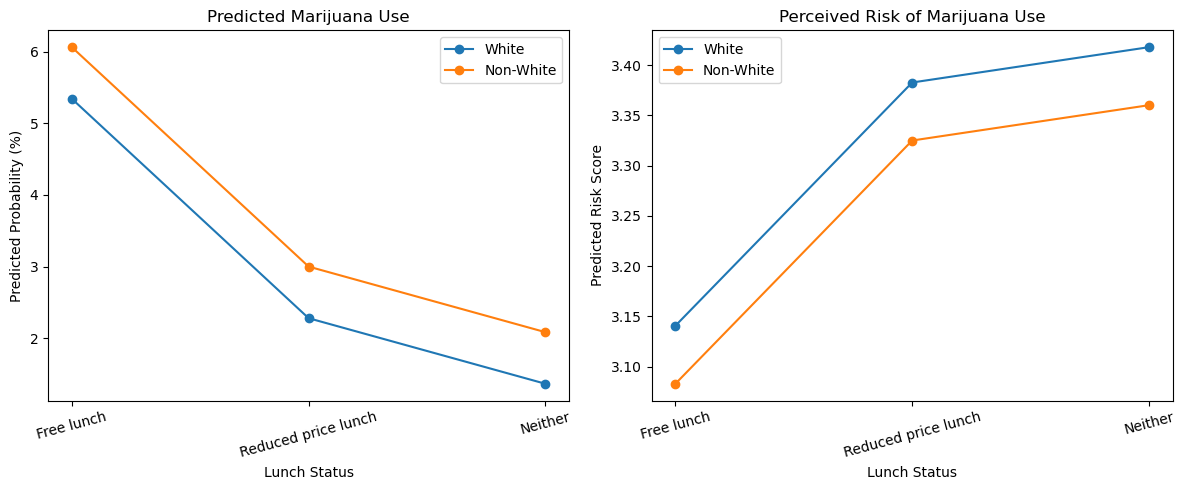

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# ----------------------------
# 1. Fit models
# ----------------------------
model_binge = smf.ols("binge_binary ~ poc_fixed + frlunch", data=df_8).fit()
model_pot = smf.ols("pot_binary ~ poc_fixed + frlunch", data=df_8).fit()
model_risk_binge = smf.ols("rsk_bng_num ~ poc_fixed + frlunch", data=df_8).fit()
model_risk_pot = smf.ols("rsk_dlyp_num ~ poc_fixed + frlunch", data=df_8).fit()

# ----------------------------
# 2. Prediction dataframe
# ----------------------------
order = ["Free lunch", "Reduced price lunch", "Neither"]

pred_df = pd.DataFrame({
    "poc_fixed": [0, 1, 0, 1, 0, 1],
    "frlunch": [
        "Free lunch", "Free lunch",
        "Reduced price lunch", "Reduced price lunch",
        "Neither", "Neither"
    ]
})

pred_df["race_group"] = ["White", "Non-White", "White", "Non-White", "White", "Non-White"]

# ----------------------------
# 3. Predicted values
# ----------------------------
pred_df["binge_pred"] = model_binge.predict(pred_df) * 100
pred_df["pot_pred"] = model_pot.predict(pred_df) * 100
pred_df["risk_binge_pred"] = model_risk_binge.predict(pred_df)
pred_df["risk_pot_pred"] = model_risk_pot.predict(pred_df)

pred_df["frlunch"] = pd.Categorical(pred_df["frlunch"], categories=order, ordered=True)
pred_df = pred_df.sort_values(["race_group", "frlunch"])

# ----------------------------
# 4. Figure 1: Binge drinking
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for race in ["White", "Non-White"]:
    sub = pred_df[pred_df["race_group"] == race]

    axes[0].plot(sub["frlunch"], sub["binge_pred"], marker="o", label=race)
    axes[1].plot(sub["frlunch"], sub["risk_binge_pred"], marker="o", label=race)

axes[0].set_title("Predicted Binge Drinking")
axes[0].set_xlabel("Lunch Status")
axes[0].set_ylabel("Predicted Probability (%)")

axes[1].set_title("Perceived Risk of Binge Drinking")
axes[1].set_xlabel("Lunch Status")
axes[1].set_ylabel("Predicted Risk Score")

for ax in axes:
    ax.legend()
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

# ----------------------------
# 5. Figure 2: Marijuana use
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for race in ["White", "Non-White"]:
    sub = pred_df[pred_df["race_group"] == race]

    axes[0].plot(sub["frlunch"], sub["pot_pred"], marker="o", label=race)
    axes[1].plot(sub["frlunch"], sub["risk_pot_pred"], marker="o", label=race)

axes[0].set_title("Predicted Marijuana Use")
axes[0].set_xlabel("Lunch Status")
axes[0].set_ylabel("Predicted Probability (%)")

axes[1].set_title("Perceived Risk of Marijuana Use")
axes[1].set_xlabel("Lunch Status")
axes[1].set_ylabel("Predicted Risk Score")

for ax in axes:
    ax.legend()
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

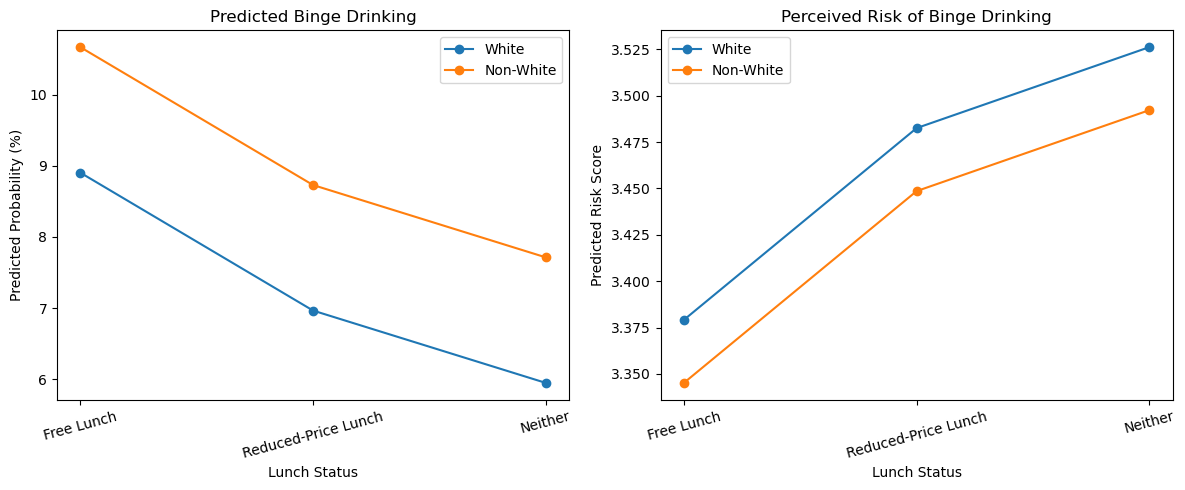

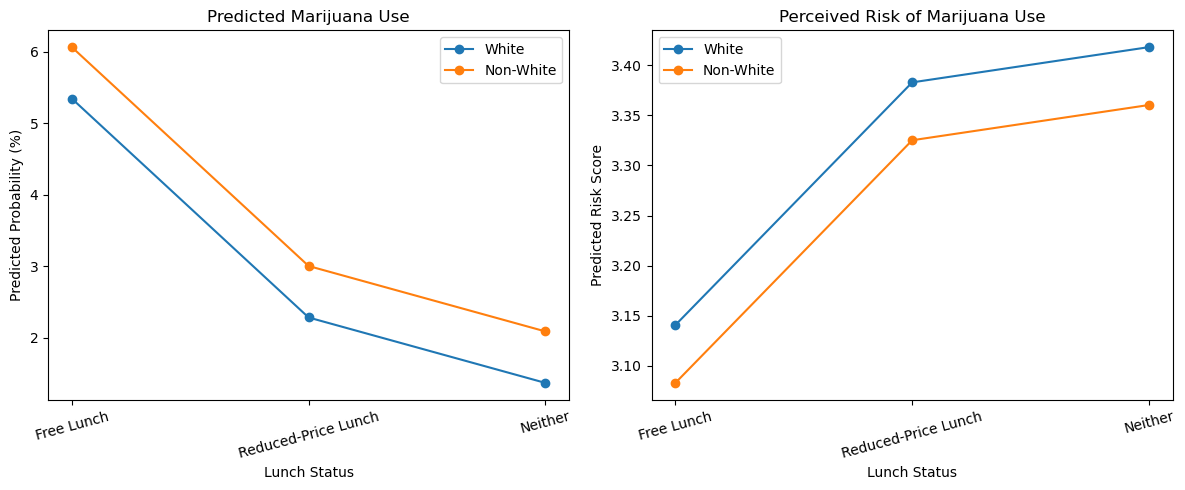

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# ----------------------------
# 1. Fit models
# ----------------------------
model_binge = smf.ols("binge_binary ~ poc_fixed + frlunch", data=df_8).fit()
model_pot = smf.ols("pot_binary ~ poc_fixed + frlunch", data=df_8).fit()
model_risk_binge = smf.ols("rsk_bng_num ~ poc_fixed + frlunch", data=df_8).fit()
model_risk_pot = smf.ols("rsk_dlyp_num ~ poc_fixed + frlunch", data=df_8).fit()

# ----------------------------
# 2. Create prediction dataframe
# Keep frlunch labels exactly as they appear in the data
# ----------------------------
order = ["Free lunch", "Reduced price lunch", "Neither"]

pred_df = pd.DataFrame({
    "poc_fixed": [0, 1, 0, 1, 0, 1],
    "frlunch": [
        "Free lunch", "Free lunch",
        "Reduced price lunch", "Reduced price lunch",
        "Neither", "Neither"
    ]
})

pred_df["race_group"] = ["White", "Non-White", "White", "Non-White", "White", "Non-White"]

# ----------------------------
# 3. Generate predictions
# ----------------------------
pred_df["binge_pred"] = model_binge.predict(pred_df) * 100
pred_df["pot_pred"] = model_pot.predict(pred_df) * 100
pred_df["risk_binge_pred"] = model_risk_binge.predict(pred_df)
pred_df["risk_pot_pred"] = model_risk_pot.predict(pred_df)

# Keep order consistent
pred_df["frlunch"] = pd.Categorical(pred_df["frlunch"], categories=order, ordered=True)
pred_df = pred_df.sort_values(["race_group", "frlunch"])

# Display labels for the graph only
display_labels = ["Free Lunch", "Reduced-Price Lunch", "Neither"]

# ----------------------------
# 4. Figure 1: Binge Drinking
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for race in ["White", "Non-White"]:
    sub = pred_df[pred_df["race_group"] == race]

    axes[0].plot(display_labels, sub["binge_pred"], marker="o", label=race)
    axes[1].plot(display_labels, sub["risk_binge_pred"], marker="o", label=race)

axes[0].set_title("Predicted Binge Drinking")
axes[0].set_xlabel("Lunch Status")
axes[0].set_ylabel("Predicted Probability (%)")

axes[1].set_title("Perceived Risk of Binge Drinking")
axes[1].set_xlabel("Lunch Status")
axes[1].set_ylabel("Predicted Risk Score")

for ax in axes:
    ax.legend()
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

# ----------------------------
# 5. Figure 2: Marijuana Use
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for race in ["White", "Non-White"]:
    sub = pred_df[pred_df["race_group"] == race]

    axes[0].plot(display_labels, sub["pot_pred"], marker="o", label=race)
    axes[1].plot(display_labels, sub["risk_pot_pred"], marker="o", label=race)

axes[0].set_title("Predicted Marijuana Use")
axes[0].set_xlabel("Lunch Status")
axes[0].set_ylabel("Predicted Probability (%)")

axes[1].set_title("Perceived Risk of Marijuana Use")
axes[1].set_xlabel("Lunch Status")
axes[1].set_ylabel("Predicted Risk Score")

for ax in axes:
    ax.legend()
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()